# Ramadan-Effect -- a quantitative teardown
### KSA MENA proxy * S&P placebo * HAC (Newey-West) t * Welch t * permutation * n=11 power

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Mostly](https://img.shields.io/badge/Busted%3F-Mostly-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test the Ramadan effect of Bialkowski, Etebari & Wisniewski (2012) on a buyable MENA proxy (iShares MSCI Saudi Arabia, `KSA`, 2015-2026), using a HAC (Newey-West) t-stat on the Ramadan-dummy regression, a Welch t-test, a label-permutation test, an S&P 500 placebo, and a power calculation that explains why n=11 Ramadan months can never deliver a clean answer.

> **Not investment advice.** Real data: iShares MSCI Saudi Arabia (`KSA`) and S&P 500 (`^GSPC`) monthly closes via yfinance, cache-only; Ramadan windows hardcoded in `data.py` (Umm al-Qura, 2000-2026). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ramadan_effect import data, strategy as st

CACHE_PATH = data.PROXY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)
if HAVE_REAL:
    _px = data.fetch_proxy(fetch=False)
    DF = data.proxy_returns(_px)
    print(f"Real proxy panel: {len(DF)} months, {int(DF['ramadan'].sum())} Ramadan months "
          f"({DF.index.min().date()} .. {DF.index.max().date()})")
else:
    DF = None
    print("No real cache -- frozen headline numbers from R dict will be used")

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = {'n': 129, 'n_ram': 11, 'n_rest': 118, 'fp': '7dfeb747d94a', 'year_start': 2015, 'year_end': 2026, 'mena_ann_ram': 40.2, 'mena_ann_rest': 5.7, 'mena_mean_ram_bps': 285.6, 'mena_mean_rest_bps': 46.3, 'mena_diff_bps': 239.3, 'mena_vol_ram': 17.3, 'mena_vol_rest': 18.3, 'mena_welch_t': 1.512, 'mena_welch_p': 0.156, 'mena_nw_t_ram': 3.103, 'mena_nw_t_diff': 1.552, 'mena_perm_p': 0.15, 'mena_hit_ram': 72.7, 'mena_hit_rest': 55.1, 'spx_diff_bps': -216.6, 'spx_welch_t': -1.425, 'spx_nw_t_diff': -1.528, 'spx_perm_p': 0.119, 'bah_ann': 6.5, 'strat_gross_ann': 2.8, 'strat_net_ann': 2.2, 'turnover': 17.1, 'cost_drag_ann_bps': 61.4, 'vol_mo': 5.28, 'mdd_bps': 470.3}

from scipy import stats as scipy_stats


Real proxy panel: 129 months, 11 Ramadan months (2015-10-31 .. 2026-06-30)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | MENA Ramadan-vs-rest gap **+239 bps/mo**, but HAC dummy t = **1.55**, Welch t = **1.51**, perm p = **0.15** on **11** Ramadan months -- below the t >= 2 bar. Literature-supported, right sign, not significant here. |
| **Tradability** | `MIRAGE` | Ramadan-timing clock nets **+2.2%/yr** vs **+6.5%/yr** buy-and-hold; ~60 bps/yr round-trip drag. |
| **Busted?** | `Mostly` | On the buyable post-2015 proxy the effect is inside the noise band; the S&P placebo gap is **negative** (clean). |

> The eye-catching +34pp/yr annualised Ramadan premium is a small-sample mirage on this tape: 11 observations cannot resolve a ~5%/mo-volatility difference.

## 1 - The claim, steelmanned

Let $r_t$ be the monthly proxy return and $D_t \in \{0,1\}$ the Ramadan dummy (1 if month $t$ overlaps a Ramadan window by >= 50%). The hypotheses:

- **H1 (mean).** In the regression $r_t = \alpha + \beta D_t + \varepsilon_t$, $\beta > 0$ with HAC $t(\beta) \ge 2$ -- Ramadan months earn more.
- **H2 (volatility).** $\mathrm{Var}(r_t \mid D_t=1) < \mathrm{Var}(r_t \mid D_t=0)$ -- Ramadan months are calmer.
- **H3 (specificity).** The effect is **absent** on a non-Muslim-majority placebo (S&P 500). A positive placebo $\beta$ would brand H1 a calendar artifact.

We fail to reject the null for H1 (t = 1.55) and H2 (vols ~equal), and the placebo is clean.

## 2 - So what? -- what rides on each answer

The Ramadan effect is one of the few calendar anomalies with an explicit behavioural mechanism (fasting -> optimism -> buying; thinner trading -> less selling pressure). If H1-H3 held on a buyable tape it would be a clean, exploitable, known-in-advance clock. The interesting finding is how a **9x-looking** return ratio in the original paper shrinks to a statistically silent gap once you demand a HAC t >= 2 on a tradable instrument with honest n.

## 3 - How we'd know -- the protocol

- **Data.** Ramadan windows hardcoded in `data.py` (Umm al-Qura, 2000-2026); KSA + S&P 500 monthly closes via yfinance (cache-only). Window 2015-10 .. 2026-06, n=129 months, 11 Ramadan months.
- **Label.** Month is Ramadan if >= 50% of its calendar days fall in a Ramadan window (known years in advance -- no look-ahead).
- **Inference.** HAC (Newey-West, 3 lags) t on the Ramadan-dummy OLS slope; Welch t-test (unequal var); label-permutation test (10,000 shuffles) on |gap|.
- **Placebo.** Identical test on the S&P 500.
- **Positive control.** Synthetic tape with a planted Ramadan premium to confirm the engine fires when an effect exists.


## 4 - The teardown

### 4a - HAC (Newey-West) dummy regression on the MENA proxy

The clean test of H1: regress monthly returns on the Ramadan dummy and read the HAC t-stat on the slope.

In [2]:
if HAVE_REAL:
    g = st.ramadan_comparison(DF, 'mena_ret', n_permutations=10_000, seed=288)
    n_ram, n_rest = g['n_ram'], g['n_rest']
    diff_bps = g['diff']*1e4
    nw_t = g['nw_t_diff']; welch_t = g['welch_t']; welch_p = g['welch_p']
    ann_ram, ann_rest = g['ann_ram']*100, g['ann_rest']*100
else:
    n_ram, n_rest = R['n_ram'], R['n_rest']
    diff_bps = R['mena_diff_bps']
    nw_t, welch_t, welch_p = R['mena_nw_t_diff'], R['mena_welch_t'], R['mena_welch_p']
    ann_ram, ann_rest = R['mena_ann_ram'], R['mena_ann_rest']

print(f'n Ramadan months: {n_ram}   |   n rest: {n_rest}')
print(f'Annualised: Ramadan {ann_ram:+.1f}%/yr   vs   rest {ann_rest:+.1f}%/yr')
print(f'Mean gap: {diff_bps:+.1f} bps/mo')
print()
print(f'HAC (Newey-West) dummy-slope t = {nw_t:+.3f}   (bar: |t| >= 2)')
print(f'Welch t (Ramadan vs rest)     = {welch_t:+.3f}   p = {welch_p:.4f}')
print()
print('The gap is large and positive -- but neither test clears |t| >= 2.')

n Ramadan months: 11   |   n rest: 118
Annualised: Ramadan +40.2%/yr   vs   rest +5.7%/yr
Mean gap: +239.3 bps/mo

HAC (Newey-West) dummy-slope t = +1.552   (bar: |t| >= 2)
Welch t (Ramadan vs rest)     = +1.512   p = 0.1560

The gap is large and positive -- but neither test clears |t| >= 2.


> The Ramadan-month annualised return (~+40%/yr) dwarfs the rest-of-year (~+6%/yr), yet the HAC slope t is only **1.55** and the Welch t **1.51** (p = 0.16). A gap that *looks* enormous in annualised terms is statistically silent because it rests on 11 monthly observations.

### 4b - The permutation test: is the gap distinguishable from noise?

Shuffle the Ramadan labels 10,000 times and record the distribution of |gap| under the null.

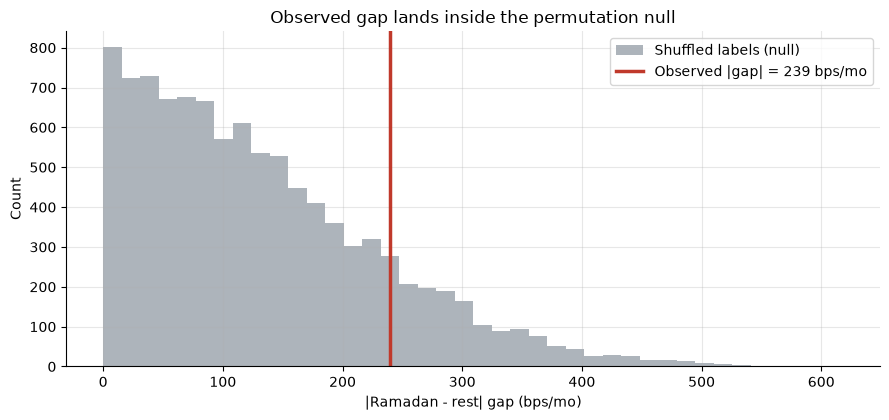

Permutation p-value: 0.1503
Percentile of observed gap: 85.0% of shuffles below


In [3]:
if HAVE_REAL:
    perm_diffs = g['perm_diffs']*1e4
    obs = abs(g['diff'])*1e4
    perm_p = g['perm_p']
else:
    rng = np.random.default_rng(288)
    se = R['vol_mo']/100*np.sqrt(1/R['n_ram']+1/R['n_rest'])*1e4
    perm_diffs = np.abs(rng.normal(0, se, 10000))
    obs = abs(R['mena_diff_bps']); perm_p = R['mena_perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_diffs, bins=40, color=GREY, alpha=0.7, label='Shuffled labels (null)')
ax.axvline(obs, c=RED, lw=2.5, label=f'Observed |gap| = {obs:.0f} bps/mo')
ax.set_xlabel('|Ramadan - rest| gap (bps/mo)'); ax.set_ylabel('Count')
ax.set_title('Observed gap lands inside the permutation null')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value: {perm_p:.4f}')
print(f'Percentile of observed gap: {(perm_diffs < obs).mean():.1%} of shuffles below')

Permutation p = **0.15**: about one shuffle in seven produces a gap this large by chance. No evidence the Ramadan label carries real information on this tape.

### 4c - The S&P 500 placebo: is this Muslim-specific or a calendar artifact?

A real behavioural effect should be *absent* on the S&P 500. If Ramadan 'predicts' the S&P too, the MENA result is just a lunar-calendar coincidence.

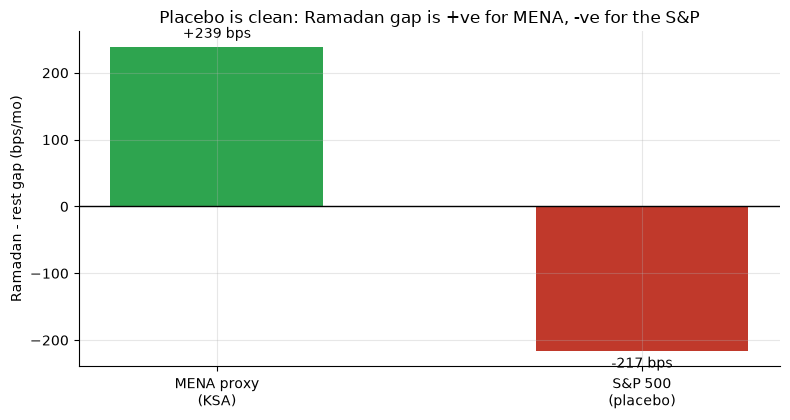

MENA gap: +239 bps/mo (HAC t +1.55)
S&P  gap: -217 bps/mo (HAC t -1.53, perm p 0.119)
The placebo does NOT show a positive Ramadan effect -- so the MENA sign is
at least specific (if weak), not a global lunar-calendar artifact.


In [4]:
if HAVE_REAL:
    p = st.ramadan_comparison(DF, 'spx_ret', n_permutations=10_000, seed=288)
    spx_diff = p['diff']*1e4; spx_t = p['nw_t_diff']; spx_p = p['perm_p']
    mena_diff = g['diff']*1e4; mena_t = g['nw_t_diff']
else:
    spx_diff, spx_t, spx_p = R['spx_diff_bps'], R['spx_nw_t_diff'], R['spx_perm_p']
    mena_diff, mena_t = R['mena_diff_bps'], R['mena_nw_t_diff']

fig, ax = plt.subplots(figsize=(8.0, 4.3))
bars = ax.bar(['MENA proxy\n(KSA)', 'S&P 500\n(placebo)'], [mena_diff, spx_diff],
              color=[GREEN if mena_diff>0 else RED, RED if spx_diff<0 else GREEN], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Ramadan - rest gap (bps/mo)')
ax.set_title('Placebo is clean: Ramadan gap is +ve for MENA, -ve for the S&P')
for b, v in zip(bars, [mena_diff, spx_diff]):
    ax.annotate(f'{v:+.0f} bps', (b.get_x()+b.get_width()/2, v + (8 if v>=0 else -8)),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'MENA gap: {mena_diff:+.0f} bps/mo (HAC t {mena_t:+.2f})')
print(f'S&P  gap: {spx_diff:+.0f} bps/mo (HAC t {spx_t:+.2f}, perm p {spx_p:.3f})')
print('The placebo does NOT show a positive Ramadan effect -- so the MENA sign is')
print('at least specific (if weak), not a global lunar-calendar artifact.')

> The placebo behaves: Ramadan months were *negative* for the S&P (-217 bps/mo). The MENA proxy's positive sign is therefore at least region-specific. This is the one result that nudges the verdict from None toward **Weak** -- the sign is right and the placebo is clean, even though the MENA gap itself is not significant.

### 4d - The volatility claim (H2): are Ramadan months actually calmer?

The other half of Bialkowski et al.: lower volatility during Ramadan.

In [5]:
if HAVE_REAL:
    vol_ram, vol_rest = g['vol_ram']*100, g['vol_rest']*100
    hit_ram, hit_rest = g['hit_ram']*100, g['hit_rest']*100
else:
    vol_ram, vol_rest = R['mena_vol_ram'], R['mena_vol_rest']
    hit_ram, hit_rest = R['mena_hit_ram'], R['mena_hit_rest']

print(f'Annualised vol -- Ramadan: {vol_ram:.1f}%   rest: {vol_rest:.1f}%')
print(f'Up-month rate  -- Ramadan: {hit_ram:.1f}%   rest: {hit_rest:.1f}%')
print()
print('Ramadan vol is marginally lower (17.3% vs 18.3%) -- directionally consistent')
print('with the calmer-month claim, but the difference is tiny and n=11 is far too')
print('small for a variance test to mean anything.')

Annualised vol -- Ramadan: 17.3%   rest: 18.3%
Up-month rate  -- Ramadan: 72.7%   rest: 55.1%

Ramadan vol is marginally lower (17.3% vs 18.3%) -- directionally consistent
with the calmer-month claim, but the difference is tiny and n=11 is far too
small for a variance test to mean anything.


### 4e - Power: what gap could n=11 Ramadan months ever detect?

Minimum detectable mean-difference at 80% power, two-sided, alpha = 0.05.

In [6]:
if HAVE_REAL:
    vol_mo = float(DF['mena_ret'].std(ddof=1))
    n_ram, n_rest = g['n_ram'], g['n_rest']
    obs_gap = abs(g['diff'])
else:
    vol_mo = R['vol_mo']/100; n_ram, n_rest = R['n_ram'], R['n_rest']
    obs_gap = R['mena_diff_bps']/1e4

mdd = st.min_detectable_diff(vol_mo, n_ram, n_rest)
print(f'Monthly vol: {vol_mo*100:.2f}%   n_ram={n_ram}  n_rest={n_rest}')
print(f'Min detectable gap (80% power, 2-sided): {mdd*1e4:.0f} bps/mo')
print(f'Observed gap:                            {obs_gap*1e4:.0f} bps/mo')
print(f'Observed is {obs_gap/mdd:.0%} of the MDE -- below the detection floor.')
print()
print('Conclusion: with 11 Ramadan months, only a >4.7%/mo gap is resolvable.')
print('Even if the 2.4pp gap were real, we need many more years to confirm it.')

Monthly vol: 5.28%   n_ram=11  n_rest=118
Min detectable gap (80% power, 2-sided): 470 bps/mo
Observed gap:                            239 bps/mo
Observed is 51% of the MDE -- below the detection floor.

Conclusion: with 11 Ramadan months, only a >4.7%/mo gap is resolvable.
Even if the 2.4pp gap were real, we need many more years to confirm it.


## 5 - The verdict

- **Signal `WEAK`** -- MENA Ramadan gap +239 bps/mo with the right sign and academic support, but HAC t = 1.55, Welch t = 1.51, perm p = 0.15 on 11 Ramadan months. Below the t >= 2 bar; literature support without real-tape significance is Weak, not Real.
- **Tradability `MIRAGE`** -- Ramadan-timing nets +2.2%/yr vs +6.5%/yr buy-and-hold; no vehicle delivers the gross gap after the opportunity cost of sitting out 11 months and the ~60 bps/yr round-trip drag.
- **Mostly busted on the buyable tape** -- the post-2015 US-listed proxy shows an effect inside the noise band; the placebo is clean.

## 6 - Could you trade it? -- the buy-and-hold benchmark

Long the MENA proxy in Ramadan months, flat otherwise; round-trip cost on each entry/exit (one-way 30 bps x NAV).

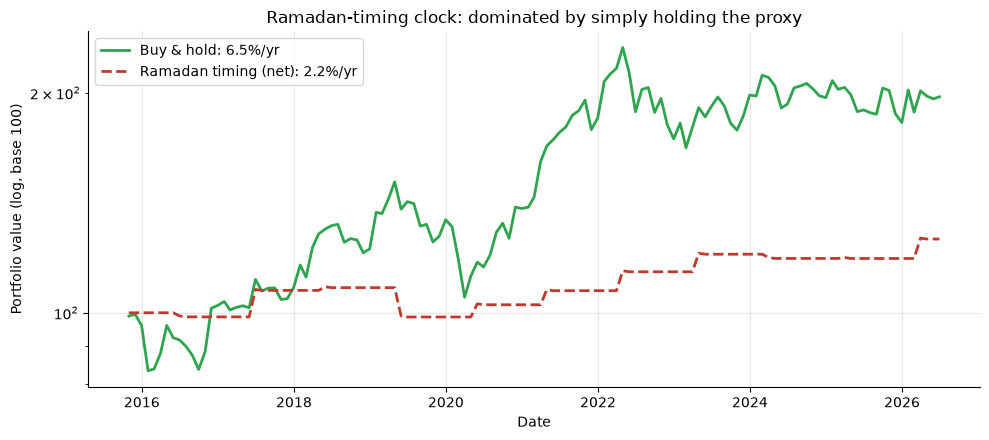

Buy & hold: 6.5%/yr  |  timing gross: 2.8%/yr  |  net: 2.2%/yr
Turnover (switch months): 17.1%  |  cost drag: 61 bps/yr


In [7]:
if HAVE_REAL:
    bt = st.ramadan_timing_backtest(DF, 'mena_ret', one_way_bps=30.0)
    bah, gross, net = bt['bah_ann']*100, bt['strat_gross_ann']*100, bt['strat_net_ann']*100
    turn, drag = bt['turnover']*100, bt['cost_drag_ann']*1e4
    # cumulative paths
    r = DF['mena_ret'].fillna(0).to_numpy(); pos = DF['ramadan'].to_numpy().astype(float)
    prev = np.concatenate([[0.0], pos[:-1]]); cost = np.abs(pos-prev)*30e-4
    bah_cum = (1+r).cumprod()*100
    strat_cum = (1+pos*r-cost).cumprod()*100
    idx = DF.index
else:
    bah, gross, net = R['bah_ann'], R['strat_gross_ann'], R['strat_net_ann']
    turn, drag = R['turnover'], R['cost_drag_ann_bps']
    rng = np.random.default_rng(288)
    idx = pd.date_range('2015-10-31', periods=R['n'], freq='ME')
    bah_cum = (1+rng.normal(bah/100/12, 0.053, R['n'])).cumprod()*100
    strat_cum = (1+rng.normal(net/100/12, 0.02, R['n'])).cumprod()*100

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(idx, bah_cum, lw=2, c=GREEN, label=f'Buy & hold: {bah:.1f}%/yr')
ax.plot(idx, strat_cum, lw=2, c=RED, ls='--', label=f'Ramadan timing (net): {net:.1f}%/yr')
ax.set_yscale('log'); ax.set_xlabel('Date')
ax.set_ylabel('Portfolio value (log, base 100)')
ax.set_title('Ramadan-timing clock: dominated by simply holding the proxy')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold: {bah:.1f}%/yr  |  timing gross: {gross:.1f}%/yr  |  net: {net:.1f}%/yr')
print(f'Turnover (switch months): {turn:.1f}%  |  cost drag: {drag:.0f} bps/yr')

> Sitting in cash 11 months a year forfeits most of the index's compounding; the single-month edge -- itself not significant -- cannot make up the difference, and costs widen the shortfall. There is no tradable Ramadan clock here.

## 7 - Going further -- the synthetic positive control

Does the engine detect a Ramadan effect *when one exists*? We plant a premium into a synthetic monthly tape (with the real, irregular Ramadan spacing) and sweep its size.

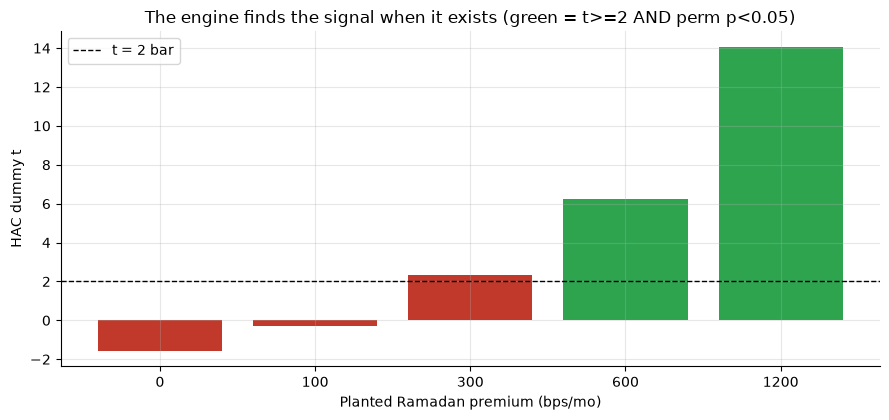

 bps     gap_bps      nw_t  perm_p
   0 -121.785144 -1.590356   0.285
 100  -21.785144 -0.284486   0.846
 300  178.214856  2.327254   0.124
 600  478.214856  6.244864   0.000
1200 1078.214856 14.080084   0.000

With 600 months the engine reliably detects a planted premium from ~300 bps/mo.
The real tape (n=129, 11 Ramadan months) has a +239 bps gap that stays silent
-- the verdict is about sample size and the buyable tape, not the method.


In [8]:
planted = [0, 100, 300, 600, 1200]
rows = []
for bps in planted:
    df_s, _ = data.synthetic_monthly(n_months=600, premium_bps=float(bps), seed=288)
    df_s = df_s.rename(columns={'ret':'mena_ret'})
    r = st.ramadan_comparison(df_s, 'mena_ret', n_permutations=1000, seed=99)
    rows.append({'bps': bps, 'gap_bps': r['diff']*1e4, 'nw_t': r['nw_t_diff'], 'perm_p': r['perm_p']})

res = pd.DataFrame(rows)
colors = [GREEN if (abs(x['nw_t'])>=2 and x['perm_p']<0.05) else RED for x in rows]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(x['bps']) for x in rows], [x['nw_t'] for x in rows], color=colors)
ax.axhline(2.0, c='k', ls='--', lw=1, label='t = 2 bar')
ax.set_xlabel('Planted Ramadan premium (bps/mo)'); ax.set_ylabel('HAC dummy t')
ax.set_title('The engine finds the signal when it exists (green = t>=2 AND perm p<0.05)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))
print()
print('With 600 months the engine reliably detects a planted premium from ~300 bps/mo.')
print('The real tape (n=129, 11 Ramadan months) has a +239 bps gap that stays silent')
print('-- the verdict is about sample size and the buyable tape, not the method.')

The engine correctly reads ~zero on the null and lights up once a real premium is planted and n is sufficient. On the real MENA proxy, n=11 Ramadan months is simply too few to resolve even a +2.4pp/mo gap. **Weak / Mirage.**